<a href="https://colab.research.google.com/github/cdolynski/xgmodel-soccer-wsl/blob/main/WSL_XGmodel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Shot Difficulty Model for Soccer

This project develops and evaluates a logistic regression model to estimate the difficulty of shots (Expected Goals/xG) in the FA Women's Super League 2020/2021 using StatsBomb open data. The model's utility is demonstrated by ranking the top 10 players by their cumulative expected goals, evaluating model calibration, and mapping spatial xG distribution across the pitch.

### Project Objectives

- Build an Expected Goals (xG) model using shot event data for the 2020/21 FA Women's Super League season.
- Provide a leaderboard of players ranked by total xG.
- Assess model performance and calibration.
- Visualize spatial xG predictions using a pitch map.

In [3]:
## Install dependencies required for StatsBomb data access and soccer visualizations
!pip install statsbombpy --quiet
!pip install mplsoccer --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.2/70.2 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.5/88.5 kB 2.8 MB/s eta 0:00:00


In [4]:
# Suppress API key warnings (using free/open data)
from statsbombpy.api_client import NoAuthWarning
import warnings
warnings.filterwarnings('ignore', category=NoAuthWarning)

**Imports**

In [5]:
import warnings
from statsbombpy import sb
from statsbombpy.api_client import NoAuthWarning
warnings.filterwarnings('ignore', category=NoAuthWarning)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mplsoccer import Pitch
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, brier_score_loss
from sklearn.calibration import calibration_curve

Define competition/season context: FA Women's Super League 2020/2021 (StatsBomb IDs)



In [6]:
league = {
    'competition_id': 37,
    'season_id': 90,
    'country_name': 'England',
    'competition_name': "FA Women's Super League",
    'season_name': '2020/2021'
}

Get shot data from statsbompy

In [7]:
def get_all_shots(competition_id, season_id):
    matches = sb.matches(competition_id=competition_id, season_id=season_id)
    all_shots = []
    for match_id in matches['match_id']:
        events = sb.events(match_id=match_id)
        shots = events[(events['type'] == 'Shot') & (events['shot_type'] != 'Penalty')]
        if not shots.empty:
            all_shots.append(shots)
    return pd.concat(all_shots, ignore_index=True) if all_shots else pd.DataFrame()

df_shots = get_all_shots(league['competition_id'], league['season_id'])
print(f"Total Shots (excluding penalties): {df_shots.shape[0]}")

Total Shots (excluding penalties): 3212


Defining Shot Difficulty - using distance to goal and goal yes/no to understand expected goal outcome

Geometry helper functions for feature construction

In [8]:
#Euclidian distance from shot location to goal center is at x = 120,y = 40 based on dataset

def calculate_distance(x, y):
    return np.sqrt((120 - x)**2 + (40 - y)**2)

Defining angle to goal using law of Cosines and goal coordinates

In [9]:
def calculate_angle(x, y):
    dx = 120 - x  # Distance along x to goal line
    dy_high = 44 - y  # To upper post (y=44)
    dy_low = 36 - y   # To lower post (y=36)
    angle_high = np.arctan2(dy_high, dx)
    angle_low = np.arctan2(dy_low, dx)
    return abs(angle_high - angle_low)

Extract coordinates from StatsBomb shot location field

In [10]:
df_shots['x'] = df_shots['location'].apply(lambda loc: loc[0])
df_shots['y'] = df_shots['location'].apply(lambda loc: loc[1])

/tmp/ipykernel_603/4128310347.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_shots['x'] = df_shots['location'].apply(lambda loc: loc[0])
/tmp/ipykernel_603/4128310347.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_shots['y'] = df_shots['location'].apply(lambda loc: loc[1])


Add spatial features: distance and angle to goal

In [11]:
df_shots['distance'] = calculate_distance(df_shots['x'], df_shots['y'])
df_shots['angle'] = calculate_angle(df_shots['x'], df_shots['y'])

/tmp/ipykernel_603/511296084.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_shots['distance'] = calculate_distance(df_shots['x'], df_shots['y'])
/tmp/ipykernel_603/511296084.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_shots['angle'] = calculate_angle(df_shots['x'], df_shots['y'])


Create binary target: goal=1, not goal=0

In [12]:
df_shots['is_goal'] = (df_shots['shot_outcome'] == 'Goal').astype(int)

/tmp/ipykernel_603/3734207015.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_shots['is_goal'] = (df_shots['shot_outcome'] == 'Goal').astype(int)


The logistic regression model uses distance and angle features to predict whether a shot resulted in a goal

In [13]:
#defining variables used for logistic regression
features = ['distance', 'angle']
X = df_shots[features]
y = df_shots['is_goal']

#Split data: 80% train, 20% test (for realistic generalization and diagnostics), random state = 42
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Fit model (increased iterations due to class imbalance)





In [14]:
#max_inter = 1000 for model stability due to imbalance from rarity of soccer goals
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

**Model of Top-10 Players by Xg**

Generate xG for all shots using the fitted logistic regression

Aggregate by player and rank by season expected goals (xG)

In [15]:
model.fit(X, y)
df_shots['xg'] = model.predict_proba(X)[:, 1]

player_xg = df_shots.groupby('player')['xg'].sum().reset_index()
top_10 = player_xg.sort_values('xg', ascending=False).head(10)
top_10['rank'] = range(1, 11)
top_10 = top_10[['rank', 'player', 'xg']]
print("\nTop 10 Players by Expected Goals:")
print(top_10.to_string(index=False))


Top 10 Players by Expected Goals:
 rank                    player        xg
    1         Samantha May Kerr 15.448450
    2          Vivianne Miedema 15.001491
    3               Ellen White  8.880107
    4       Samantha June Mewis  7.435009
    5 Pernille Mosegaard Harder  7.260796
    6           Bethany England  6.962044
    7             Martha Thomas  6.317072
    8                Ella Toone  6.200478
    9               Chloe Kelly  5.671888
   10        Caitlin Jade Foord  5.516002


/tmp/ipykernel_603/4250628361.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_shots['xg'] = model.predict_proba(X)[:, 1]


**Evaluate model performance with summary metrics**

In [16]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

y_prob = model.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= 0.5).astype(int)

baseline_accuracy = (y_test == 0).sum() / len(y_test)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)
brier = brier_score_loss(y_test, y_prob)
recall = recall_score(y_test, y_pred)

# Print results
print(f"Baseline Accuracy: {baseline_accuracy:.4f}")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"ROC AUC: {auc:.4f}")
print(f"Brier Score: {brier:.4f}")
print(f"Recall: {recall:.4f}")

Baseline Accuracy: 0.8942
Accuracy: 0.8958
Precision: 0.6667
ROC AUC: 0.7499
Brier Score: 0.0843
Recall: 0.0294


Explanation of numbers
- model shows limited benefits in terms of accuracy when compared to baseline
- the model has some precision but could be better
- An AUC of ~0.75 shows moderate discriminative ability, meaning the model can separate positives from negatives reasonably well
- A Brier score this low suggests the model’s probability estimates are well calibrated and generally reliable
- low recall means the model misses many true goals which becomes more apparent in the next steps comparing Xg to actual



For interest/visual sake, I decided to add a ranking category for clarity along with a comparison of their actual goals to see how the model did at predicting

In [17]:
# Group by player and sum xG and actual goals
player_xg = df_shots.groupby('player').agg({'xg': 'sum', 'is_goal': 'sum'}).reset_index()
player_xg = player_xg.rename(columns={'is_goal': 'goals'})

# Sort by xG and select top 10
top_10 = player_xg.sort_values('xg', ascending=False).head(10)

# Add ranking column (1 to 10)
top_10['rank'] = range(1, 11)

# Reorder columns to show rank first
top_10 = top_10[['rank', 'player', 'xg', 'goals']]

# Print the table
print("\nTop 10 Players by Expected Goals vs Actual Goals:")
print(top_10.to_string(index=False))


Top 10 Players by Expected Goals vs Actual Goals:
 rank                    player        xg  goals
    1         Samantha May Kerr 15.448450     21
    2          Vivianne Miedema 15.001491     18
    3               Ellen White  8.880107     10
    4       Samantha June Mewis  7.435009      7
    5 Pernille Mosegaard Harder  7.260796      8
    6           Bethany England  6.962044      6
    7             Martha Thomas  6.317072      4
    8                Ella Toone  6.200478      7
    9               Chloe Kelly  5.671888      8
   10        Caitlin Jade Foord  5.516002     10


When comparing the models Xg to the actual, the model undershoot the value

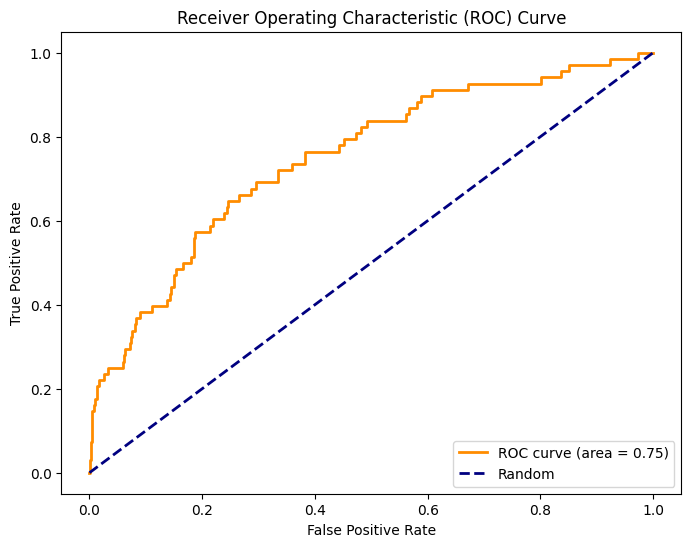

In [ ]:
from sklearn.metrics import roc_curve, auc

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

ROC-AUC of 0.74 shows that the model has a relatively good chance (74%) of predicting meaningful patterns. A higher score closer to 1.0 would be better

Creating the Calibration Curve

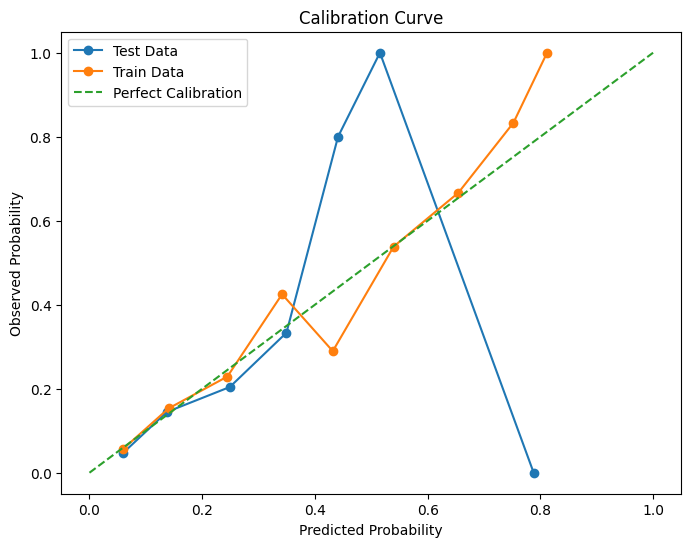

In [ ]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

# Calculate calibration curve for test data
prob_true_test, prob_pred_test = calibration_curve(y_test, y_prob, n_bins=10, strategy='uniform')

# Calculate predicted probabilities for training data
y_prob_train = model.predict_proba(X_train)[:, 1]

# Calculate calibration curve for training data
prob_true_train, prob_pred_train = calibration_curve(y_train, y_prob_train, n_bins=10, strategy='uniform')

# Plot calibration curves
fig_cal, ax_cal = plt.subplots(figsize=(8, 6))
ax_cal.plot(prob_pred_test, prob_true_test, marker='o', label='Test Data')
ax_cal.plot(prob_pred_train, prob_true_train, marker='o', label='Train Data')
ax_cal.plot([0, 1], [0, 1], linestyle='--', label='Perfect Calibration')
ax_cal.set_xlabel('Predicted Probability')
ax_cal.set_ylabel('Observed Probability')
ax_cal.set_title('Calibration Curve')
ax_cal.legend()
plt.show()

This model shows that at higher probability of a goal, the actual observed proportion of goals is lower than predicted. The model might be slightly overconfident in its higher probability predictions.
- this confirms our low recall numbers

**Plot a surface with mplsoccer that demonstrates spatial distribution of across the field**

In [ ]:
#define characteristics of the pitch
pitch_length, pitch_width = 120, 80
xx, yy = np.meshgrid(np.linspace(0, pitch_length, 120), np.linspace(0, pitch_width, 80))
grid_points = pd.DataFrame({
    'x': xx.flatten(),
    'y': yy.flatten()
})
grid_points['distance'] = calculate_distance(grid_points['x'], grid_points['y'])
grid_points['angle'] = calculate_angle(grid_points['x'], grid_points['y'])

#only use goals with distance > 0 , use our logistic regression model to predict xg for each point
grid_points = grid_points[grid_points['distance'] > 0]
xg_grid = model.predict_proba(grid_points[['distance', 'angle']])[:, 1]

#function allows us to take predicted xG values and turn them into regular grid points to cover the entire pitch
from scipy.interpolate import griddata

xi = np.linspace(0, pitch_length, 120)
yi = np.linspace(0, pitch_width, 80)
zi = griddata(
    (grid_points['x'], grid_points['y']),
    xg_grid,
    (xx, yy),
    method='linear',
    fill_value=0
)

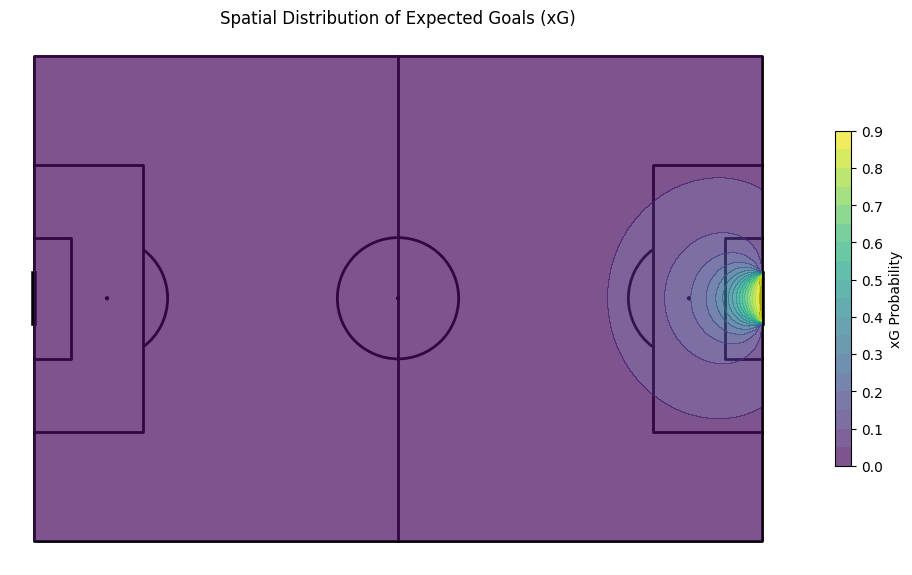

In [ ]:
# Plot the surface on the pitch
from mplsoccer import Pitch
pitch = Pitch(pitch_type='statsbomb', line_color='black')
fig, ax = pitch.draw(figsize=(10, 7))
contour = ax.contourf(xx, yy, zi, levels=20, cmap='viridis', alpha=0.7)
fig.colorbar(contour, ax=ax, shrink=0.5, label='xG Probability')
ax.set_title('Spatial Distribution of Expected Goals (xG)')
plt.show()

Extra: Wanted to see why distribution of graphs show low probability so close to the 18 yard box as many goals seem to take place past this.

Data below shows that of 250 shots >30 yards only 14 were goals so the graph does make sense

In [ ]:
long_shots = df_shots[df_shots['distance'] > 30]

number_of_shots = len(long_shots)
number_of_goals = long_shots['is_goal'].sum()

long_shot_summary = pd.DataFrame({
    'Category': ['Number of Shots', 'Goals from Long Shots'],
    'Count': [number_of_shots, number_of_goals]
})

print("\nSummary of Long Shots (> 30 yards):")
print(long_shot_summary.to_string(index=False))


Summary of Long Shots (> 30 yards):
             Category  Count
      Number of Shots    250
Goals from Long Shots     14


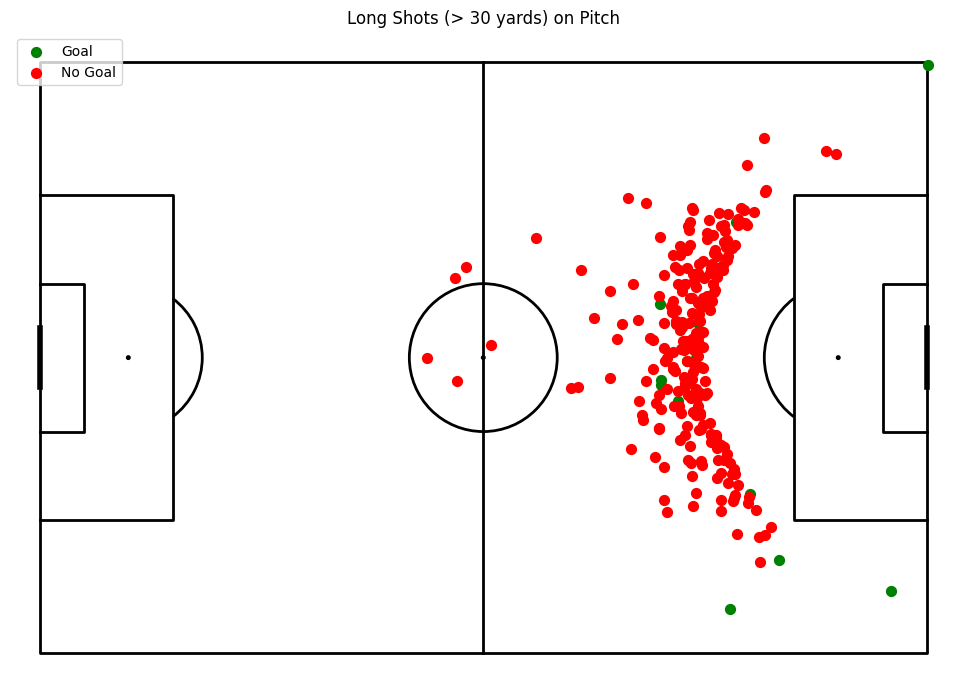

In [ ]:
# Filter long shots into goals and non-goals
long_shot_goals = long_shots[long_shots['is_goal'] == 1]
long_shot_no_goals = long_shots[long_shots['is_goal'] == 0]

# Plot
pitch = Pitch(pitch_type='statsbomb', line_color='black')
fig, ax = pitch.draw(figsize=(10, 7))

pitch.scatter(long_shot_goals['x'], long_shot_goals['y'], color='green', s=50, ax=ax, label='Goal')
pitch.scatter(long_shot_no_goals['x'], long_shot_no_goals['y'], color='red', s=50, ax=ax, label='No Goal')

ax.set_title('Long Shots (> 30 yards) on Pitch')
ax.legend()

plt.show()